In [1]:
import pickle, numpy as np

with open(r"\\Hive3014\znn\YuanqiHua\High speed\260123 wt1 MTZ\pkl_output\wt1-MTZ-1_0_binary.pkl","rb") as f:
    tf = pickle.load(f)

# 1) 每帧是否都是 ndarray 且 shape 一样
shapes = [getattr(x, "shape", None) for x in tf]
print("unique shapes:", sorted(set(shapes)))

# 2) 是否能变成规则 3D array
arr = np.array(tf)
print("arr.shape:", arr.shape, "dtype:", arr.dtype)


unique shapes: [(20, 2)]
arr.shape: (460, 20, 2) dtype: float32


[OK] wt1-MTZ-1_0_binary.pkl | flagged=42 fixed=42
[OK] wt1-MTZ-1_10_binaryxxx.pkl | flagged=56 fixed=56
[OK] wt1-MTZ-1_11_binary.pkl | flagged=20 fixed=20
[OK] wt1-MTZ-1_1_binary.pkl | flagged=1 fixed=1
[OK] wt1-MTZ-1_2_binary.pkl | flagged=2 fixed=2
[OK] wt1-MTZ-1_3_binary.pkl | flagged=69 fixed=69
[OK] wt1-MTZ-1_4_binaryxxxx.pkl | flagged=40 fixed=40


KeyboardInterrupt: 

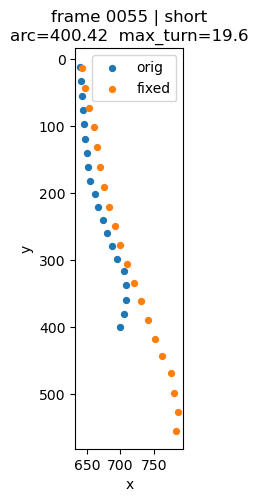

In [2]:
import io
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import csv

# =============================
# 0) 你只需要改这里
# =============================
INPUT_DIR  = Path(r"\\Hive3014\znn\YuanqiHua\High speed\260123 wt1 MTZ\pkl_output")  # <<< 改成你的pkl文件夹
OUTPUT_DIR = INPUT_DIR / "pkl_review_out"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- 异常判定阈值（可按你数据微调）----
SHORT_RATIO = 0.60     # 弧长 < SHORT_RATIO * median_arc => short（更严格可 0.50~0.55）
FOLD90_DEG  = 90.0     # 最大局部转角 >= 90 => fold90
TURN150_DEG = 150.0    # 最大局部转角 >= 150 => turn150

# ---- 修复策略（用前后好帧插值）----
FIX_MIN_RUN = 1        # 连续坏帧长度 >= 1 就修；想忽略单帧毛刺可设 2

# ---- 导出控制（避免图片爆炸）----
EXPORT_MAX_FRAMES_PER_FILE = 200  # 每个文件最多导出多少张异常帧图（够用了）

# =============================
# 1) 兼容读取 pickle（处理 numpy._core）
# =============================
class NumpyCoreCompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core", 1)
        return super().find_class(module, name)

def load_pkl_compat(pkl_path: Path):
    data = pkl_path.read_bytes()
    tf = NumpyCoreCompatUnpickler(io.BytesIO(data)).load()
    tf = np.asarray(tf, dtype=np.float32)
    if tf.ndim != 3 or tf.shape[2] != 2:
        raise ValueError(f"Unexpected shape {tf.shape} in {pkl_path.name} (expect frames x points x 2)")
    return tf

# =============================
# 2) 指标：弧长 / 最大转角 / 自交叉
# =============================
def tail_arclength(tf):
    d = np.diff(tf, axis=1)                    # (F, P-1, 2)
    seg = np.sqrt((d * d).sum(axis=2))         # (F, P-1)
    return seg.sum(axis=1)                     # (F,)

def max_turn_angle_per_frame(tf):
    F, P, _ = tf.shape
    max_turn = np.zeros(F, dtype=np.float32)
    max_joint = np.zeros(F, dtype=np.int32)
    eps = 1e-9
    for f in range(F):
        pts = tf[f]
        v1 = pts[1:-1] - pts[:-2]
        v2 = pts[2:]   - pts[1:-1]
        n1 = np.sqrt((v1*v1).sum(axis=1)) + eps
        n2 = np.sqrt((v2*v2).sum(axis=1)) + eps
        cos = (v1*v2).sum(axis=1) / (n1*n2)
        cos = np.clip(cos, -1.0, 1.0)
        ang = np.degrees(np.arccos(cos))       # 0..180
        j = int(np.argmax(ang))
        max_turn[f] = float(ang[j])
        max_joint[f] = j + 1                   # 关节索引（对应 pts 的 index）
    return max_turn, max_joint

def _seg_intersect(a, b, c, d):
    def orient(p, q, r):
        return (q[0]-p[0])*(r[1]-p[1]) - (q[1]-p[1])*(r[0]-p[0])
    def onseg(p, q, r):
        return (min(p[0],r[0]) <= q[0] <= max(p[0],r[0]) and
                min(p[1],r[1]) <= q[1] <= max(p[1],r[1]))
    o1 = orient(a,b,c); o2 = orient(a,b,d)
    o3 = orient(c,d,a); o4 = orient(c,d,b)
    if (o1*o2 < 0) and (o3*o4 < 0):
        return True
    if o1 == 0 and onseg(a,c,b): return True
    if o2 == 0 and onseg(a,d,b): return True
    if o3 == 0 and onseg(c,a,d): return True
    if o4 == 0 and onseg(c,b,d): return True
    return False

def self_intersection_mask(tf):
    F, P, _ = tf.shape
    out = np.zeros(F, dtype=bool)
    for f in range(F):
        pts = tf[f]
        for i in range(P-1):
            a = pts[i]; b = pts[i+1]
            for j in range(i+2, P-1):
                if j == i+1:
                    continue
                c = pts[j]; d = pts[j+1]
                if _seg_intersect(a,b,c,d):
                    out[f] = True
                    break
            if out[f]:
                break
    return out

# =============================
# 3) 生成“坏帧 mask”（用于修复：short/turn/selfx 任意触发）
# =============================
def compress_bad_by_minrun(bad_mask, min_run):
    if min_run <= 1:
        return bad_mask
    idx = np.where(bad_mask)[0]
    if idx.size == 0:
        return bad_mask

    keep = np.zeros_like(bad_mask)
    s = idx[0]; prev = idx[0]
    for i in idx[1:]:
        if i == prev + 1:
            prev = i
        else:
            if (prev - s + 1) >= min_run:
                keep[s:prev+1] = True
            s = prev = i
    if (prev - s + 1) >= min_run:
        keep[s:prev+1] = True
    return keep

def build_flags(tf):
    arc = tail_arclength(tf)
    med = float(np.median(arc[np.isfinite(arc)]))
    short = arc < (SHORT_RATIO * med)

    max_turn, _ = max_turn_angle_per_frame(tf)
    fold90  = max_turn >= FOLD90_DEG
    turn150 = max_turn >= TURN150_DEG

    selfx = self_intersection_mask(tf)

    # 标注用途：全部异常
    flags_mask = short | fold90 | turn150 | selfx
    flagged_idx = np.where(flags_mask)[0].astype(int)

    # 给每帧列原因（turn150 优先于 fold90）
    reasons = {}
    for i in flagged_idx:
        r = []
        if short[i]:   r.append("short")
        if turn150[i]: r.append("turn150")
        elif fold90[i]:r.append("fold90")
        if selfx[i]:   r.append("self_intersect")
        reasons[int(i)] = r

    info = {
        "arc": arc,
        "arc_median": med,
        "max_turn": max_turn,
        "short": short,
        "fold90": fold90,
        "turn150": turn150,
        "self_intersect": selfx,
        "flagged_idx": flagged_idx,
        "reasons": reasons
    }
    return info

# =============================
# 4) 修复：把“坏帧”用前后好帧插值替换（不删帧）
# =============================
def fix_frames(tf, bad_mask):
    F = tf.shape[0]
    tf_fixed = tf.copy()

    good = ~bad_mask
    prev_good = np.full(F, -1, dtype=int)
    last = -1
    for i in range(F):
        if good[i]:
            last = i
        prev_good[i] = last

    next_good = np.full(F, -1, dtype=int)
    last = -1
    for i in range(F-1, -1, -1):
        if good[i]:
            last = i
        next_good[i] = last

    bad_idx = np.where(bad_mask)[0]
    for i in bad_idx:
        a = prev_good[i]
        b = next_good[i]
        if a >= 0 and b >= 0 and a != b:
            t = (i - a) / (b - a)
            tf_fixed[i] = (1 - t) * tf_fixed[a] + t * tf_fixed[b]
        elif a >= 0:
            tf_fixed[i] = tf_fixed[a]
        elif b >= 0:
            tf_fixed[i] = tf_fixed[b]
    return tf_fixed

# =============================
# 5) 导出：异常帧散点图（orig红、fixed绿）
# =============================
def save_scatter_frame(out_png, pts_orig, pts_fixed, frame_idx, reasons, arc_val, turn_val):
    plt.figure(figsize=(5.2, 5.2))

    # orig 红
    plt.scatter(pts_orig[:,0], pts_orig[:,1], s=18, label="orig")
    # fixed 绿
    plt.scatter(pts_fixed[:,0], pts_fixed[:,1], s=18, label="fixed")

    plt.gca().invert_yaxis()
    plt.gca().set_aspect("equal", adjustable="box")
    title = f"frame {frame_idx:04d} | " + ",".join(reasons) + f"\narc={arc_val:.2f}  max_turn={turn_val:.1f}"
    plt.title(title)
    plt.xlabel("x"); plt.ylabel("y")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

# =============================
# 6) 批处理
# =============================
def process_one_file(pkl_path: Path):
    tf = load_pkl_compat(pkl_path)
    F, P, _ = tf.shape

    info = build_flags(tf)
    flagged_idx = info["flagged_idx"]
    reasons = info["reasons"]

    # 用“异常帧”来修（你也可以只修 short，把 bad_mask 改成 info["short"]）
    bad_mask = (info["short"] | info["fold90"] | info["turn150"] | info["self_intersect"])
    bad_mask = compress_bad_by_minrun(bad_mask, FIX_MIN_RUN)

    tf_fixed = fix_frames(tf, bad_mask)

    # 输出 fixed pkl
    out_pkl = OUTPUT_DIR / (pkl_path.stem + "_fixed.pkl")
    with open(out_pkl, "wb") as f:
        pickle.dump(tf_fixed, f)

    # 输出 flags 文本（所有被标注的帧）
    out_flags = OUTPUT_DIR / (pkl_path.stem + "_flags.txt")
    lines = []
    for i in flagged_idx:
        lines.append(
            f"{i}\t{','.join(reasons[i])}\tarc={info['arc'][i]:.3f}\tmax_turn={info['max_turn'][i]:.2f}"
        )
    out_flags.write_text("\n".join(lines), encoding="utf-8")

    # 输出异常帧散点图
    frame_dir = OUTPUT_DIR / (pkl_path.stem + "_frames")
    frame_dir.mkdir(exist_ok=True)

    # 如果异常帧太多，按“更极端”的优先导出：max_turn降序 + arc升序
    idx = flagged_idx.copy()
    if idx.size > 0:
        idx_sorted = sorted(idx.tolist(), key=lambda i: (-float(info["max_turn"][i]), float(info["arc"][i])))
        idx_sorted = idx_sorted[:EXPORT_MAX_FRAMES_PER_FILE]
        for i in idx_sorted:
            out_png = frame_dir / f"frame_{i:04d}.png"
            save_scatter_frame(
                out_png,
                tf[i],
                tf_fixed[i],
                i,
                reasons[i],
                float(info["arc"][i]),
                float(info["max_turn"][i]),
            )

    # summary row
    row = {
        "file": pkl_path.name,
        "frames": F,
        "points": P,
        "flagged": int(flagged_idx.size),
        "short": int(info["short"].sum()),
        "fold90": int(info["fold90"].sum()),
        "turn150": int(info["turn150"].sum()),
        "self_intersect": int(info["self_intersect"].sum()),
        "fixed_frames": int(bad_mask.sum()),
        "arc_median": float(info["arc_median"]),
    }
    return row

def main():
    pkl_files = sorted(INPUT_DIR.glob("*.pkl"))
    if not pkl_files:
        print("No .pkl found in:", INPUT_DIR)
        return

    summary = []
    for p in pkl_files:
        try:
            row = process_one_file(p)
            summary.append(row)
            print(f"[OK] {p.name} | flagged={row['flagged']} fixed={row['fixed_frames']}")
        except Exception as e:
            print("[FAIL]", p.name, "->", e)

    # 写 summary
    out_csv = OUTPUT_DIR / "review_summary.csv"
    if summary:
        with open(out_csv, "w", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=list(summary[0].keys()))
            w.writeheader()
            w.writerows(summary)
        print("DONE. Summary:", out_csv)
    else:
        print("DONE. No outputs.")

if __name__ == "__main__":
    main()


Total pkl: 53 | Start from index 1: wt1-MTZ-1_0_binary.pkl

[1/53] Reviewing: wt1-MTZ-1_0_binary.pkl


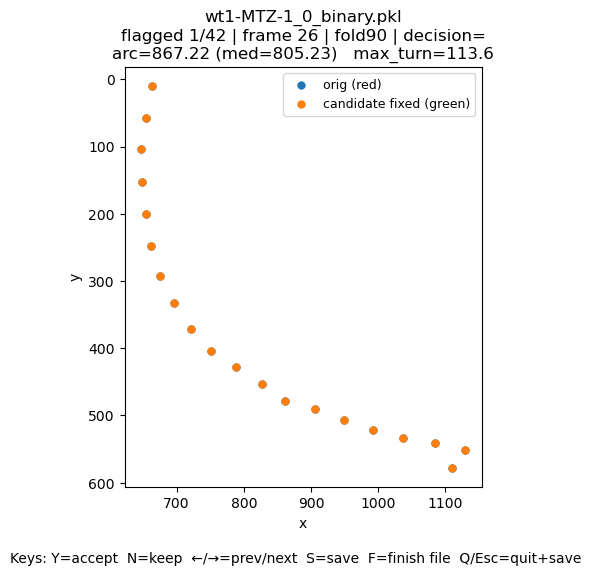


[2/53] Reviewing: wt1-MTZ-1_10_binaryxxx.pkl


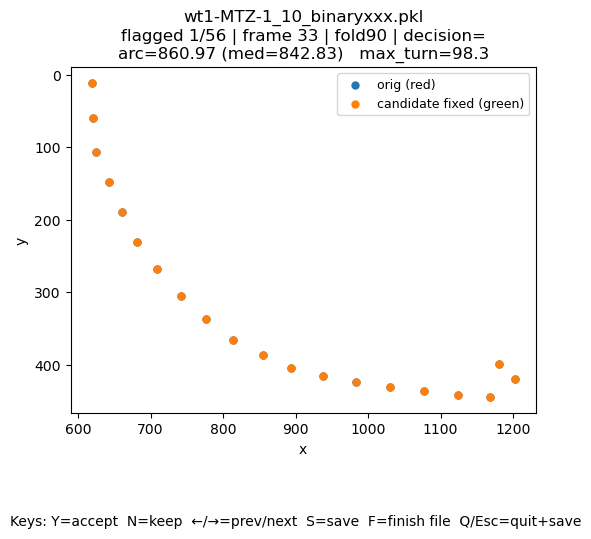


[3/53] Reviewing: wt1-MTZ-1_11_binary.pkl


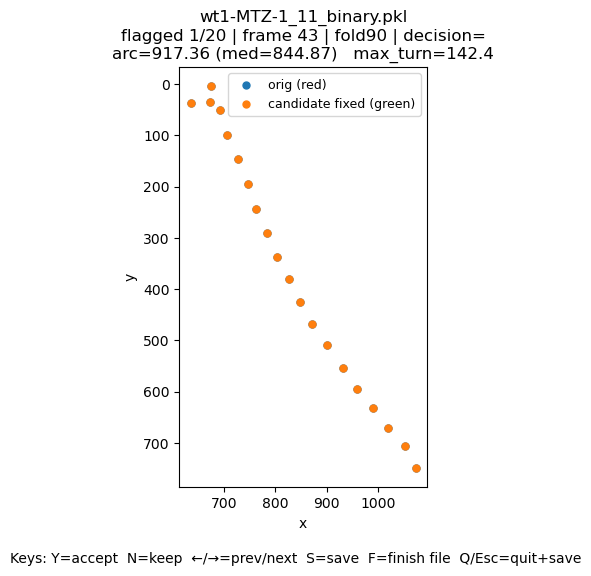


[4/53] Reviewing: wt1-MTZ-1_1_binary.pkl


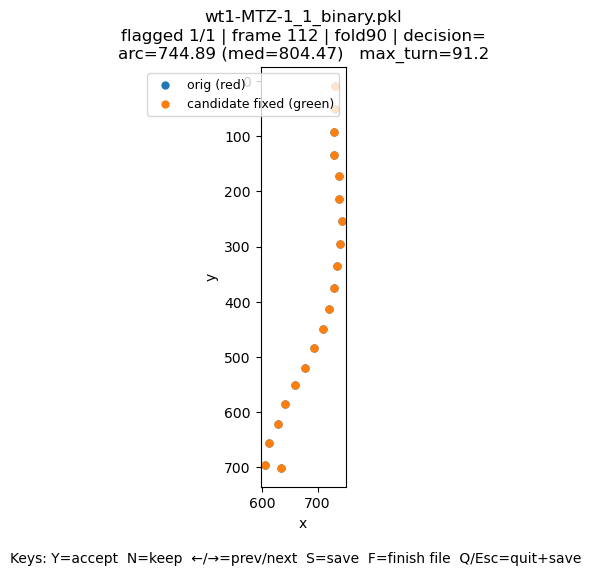


[5/53] Reviewing: wt1-MTZ-1_2_binary.pkl


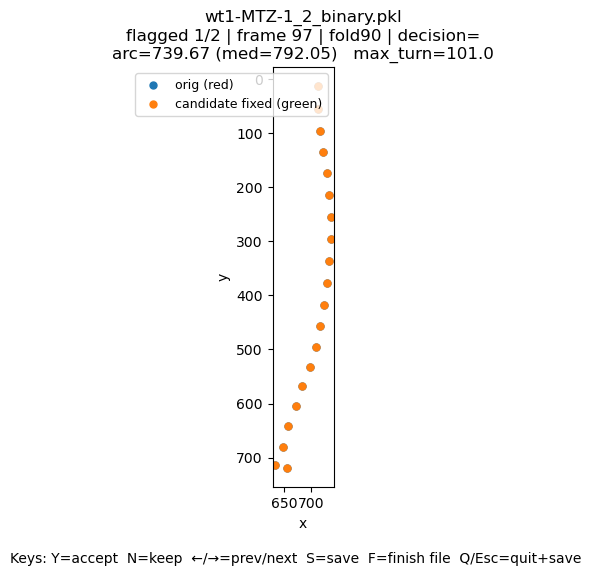


[6/53] Reviewing: wt1-MTZ-1_3_binary.pkl


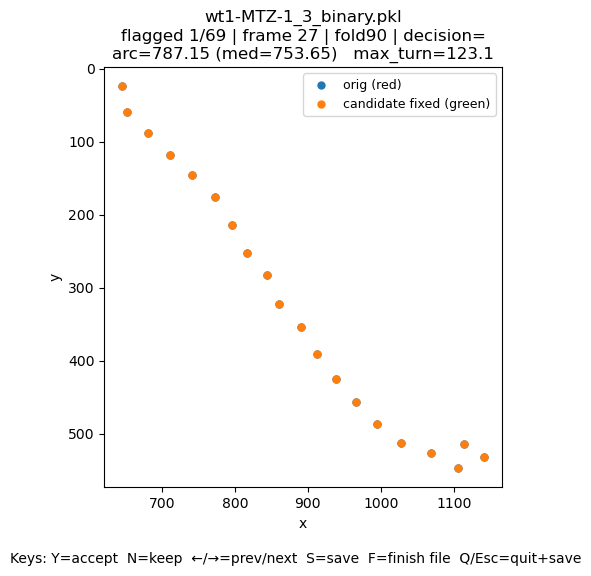


[7/53] Reviewing: wt1-MTZ-1_4_binaryxxxx.pkl


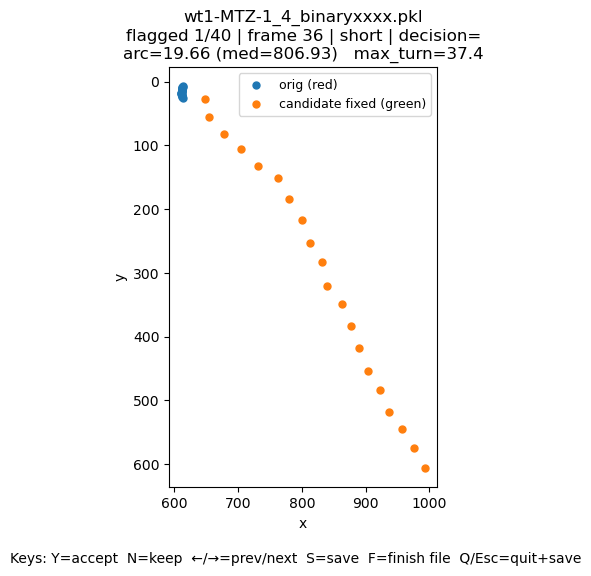


[8/53] Reviewing: wt1-MTZ-1_5_binaryxxxx.pkl


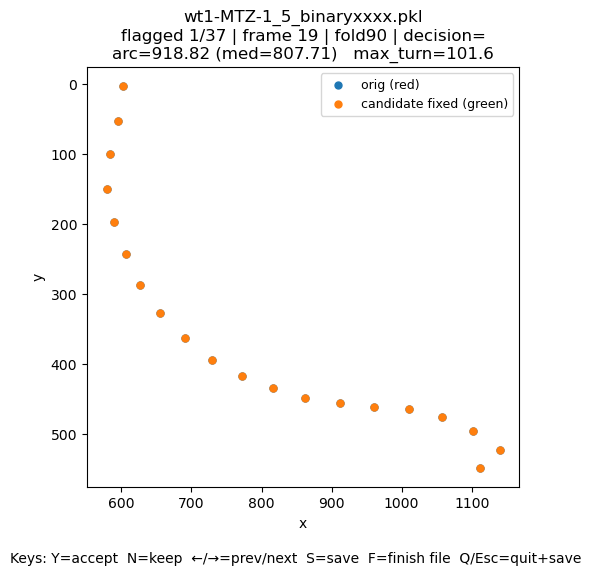


[9/53] Reviewing: wt1-MTZ-1_6_binary.pkl


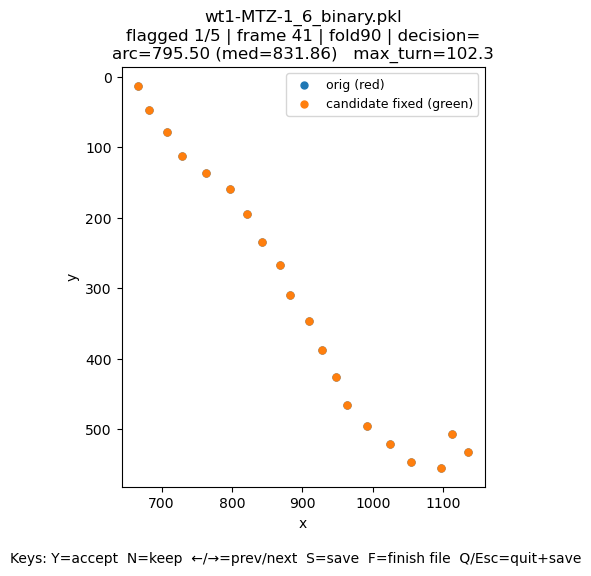


[10/53] Reviewing: wt1-MTZ-1_7_binaryxxxx.pkl


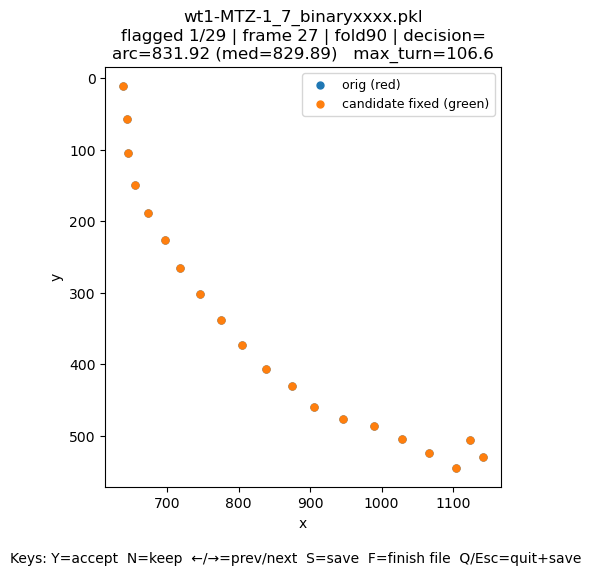


[11/53] Reviewing: wt1-MTZ-1_8_binaryxxxx.pkl


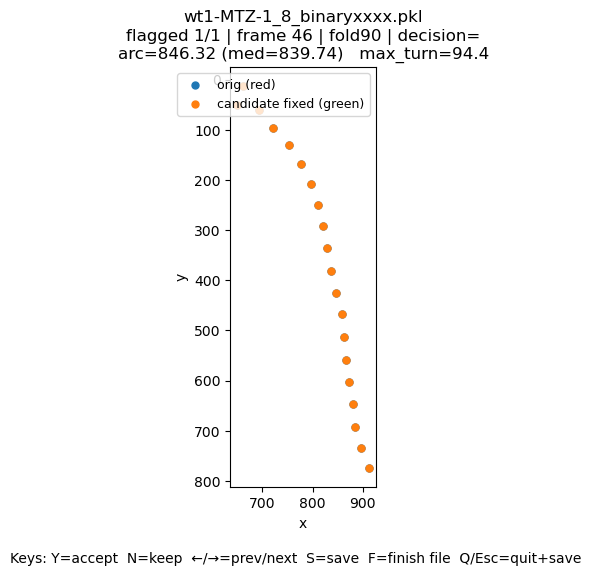


[12/53] Reviewing: wt1-MTZ-1_9_binary.pkl


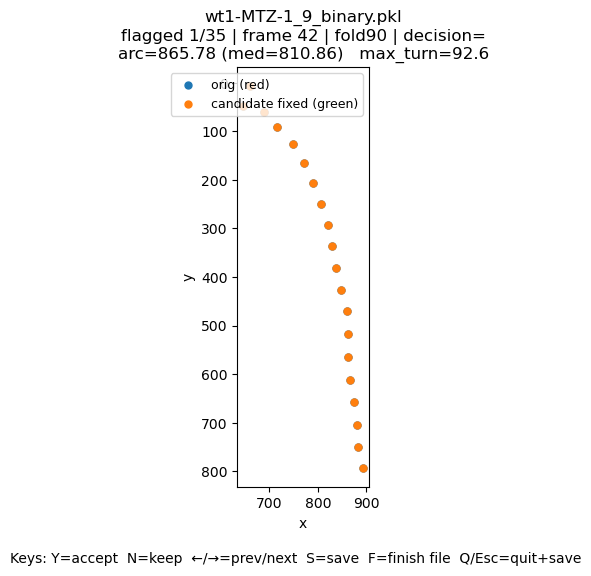


[13/53] Reviewing: wt1-MTZ-2_0_binary.pkl


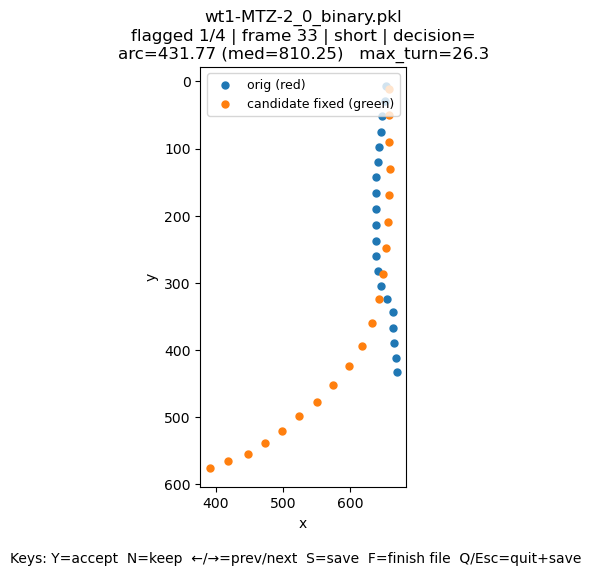


[14/53] Reviewing: wt1-MTZ-2_10_binary.pkl

[15/53] Reviewing: wt1-MTZ-2_11_binary.pkl

[16/53] Reviewing: wt1-MTZ-2_12_binary.pkl

[17/53] Reviewing: wt1-MTZ-2_13_binary.pkl


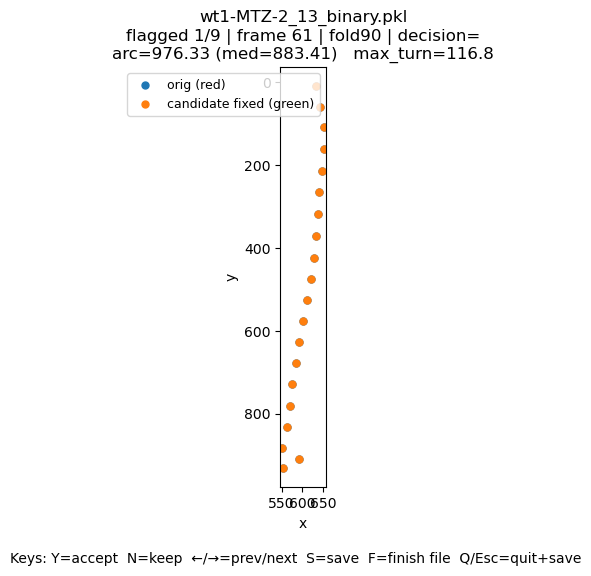


[18/53] Reviewing: wt1-MTZ-2_14_binary.pkl

[19/53] Reviewing: wt1-MTZ-2_15_binary.pkl

[20/53] Reviewing: wt1-MTZ-2_16_binary.pkl

[21/53] Reviewing: wt1-MTZ-2_1_binary.pkl

[22/53] Reviewing: wt1-MTZ-2_2_binary.pkl

[23/53] Reviewing: wt1-MTZ-2_3_binary.pkl

[24/53] Reviewing: wt1-MTZ-2_4_binary.pkl


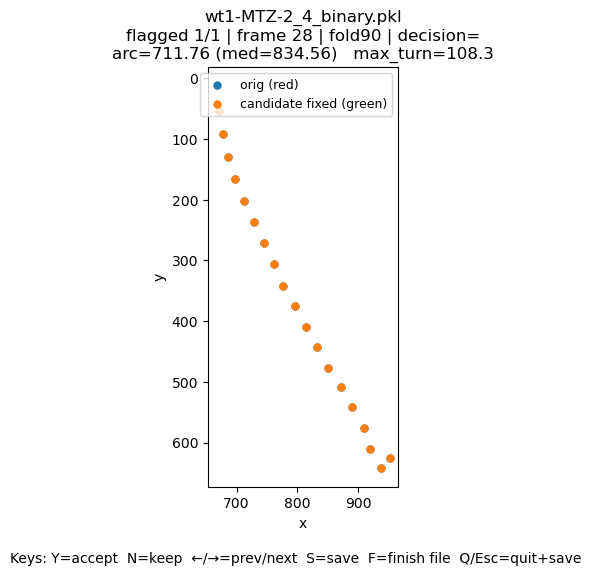


[25/53] Reviewing: wt1-MTZ-2_5_binary.pkl

[26/53] Reviewing: wt1-MTZ-2_6_binary.pkl

[27/53] Reviewing: wt1-MTZ-2_7_binary.pkl

[28/53] Reviewing: wt1-MTZ-2_8_binary.pkl

[29/53] Reviewing: wt1-MTZ-2_9_binary.pkl

[30/53] Reviewing: wt1-MTZ-3_0_binary.pkl

[31/53] Reviewing: wt1-MTZ-3_1_binary.pkl


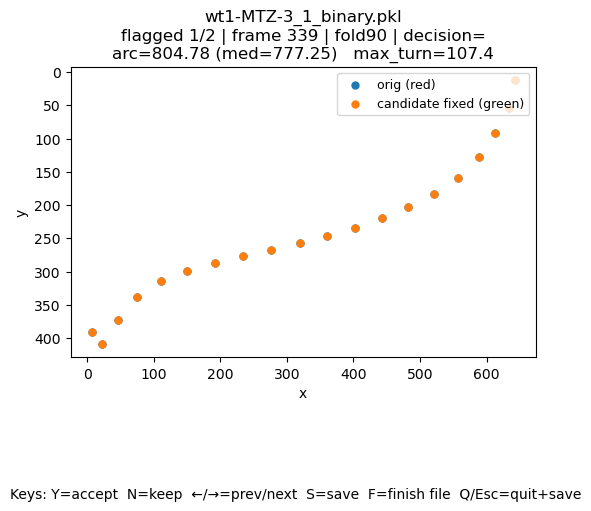


[32/53] Reviewing: wt1-MTZ-3_2_binary.pkl

[33/53] Reviewing: wt1-MTZ-3_3_binary.pkl

[34/53] Reviewing: wt1-MTZ-3_6_binary.pkl

[35/53] Reviewing: wt1-MTZ-3_7_binary.pkl


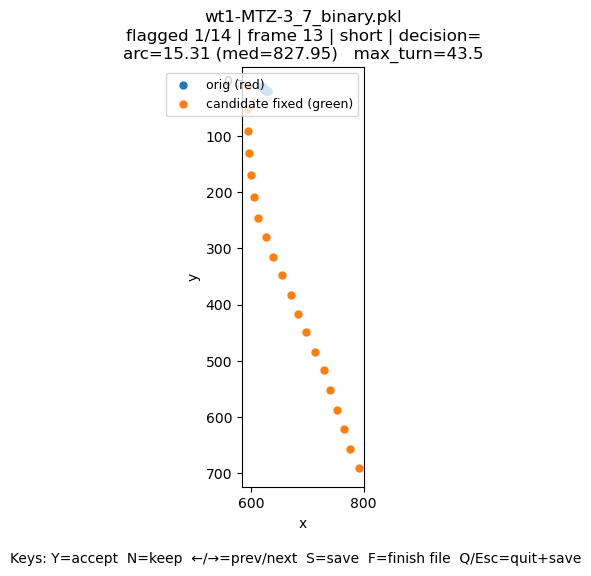


[36/53] Reviewing: wt1-MTZ-4_0_binary.pkl


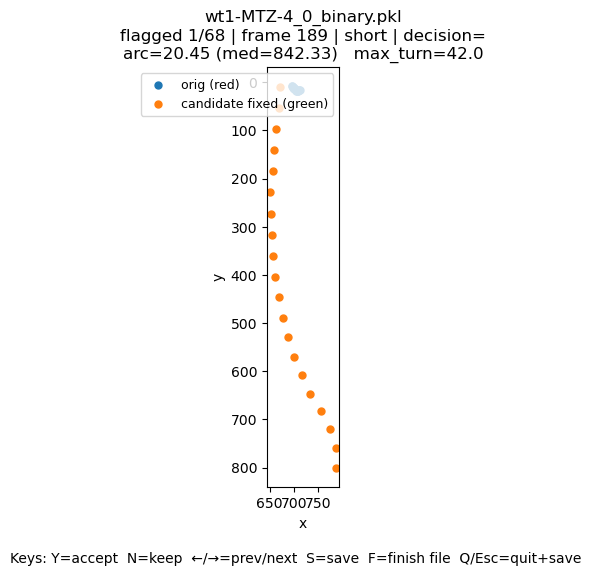


[37/53] Reviewing: wt1-MTZ-4_1_binaryxxxx.pkl


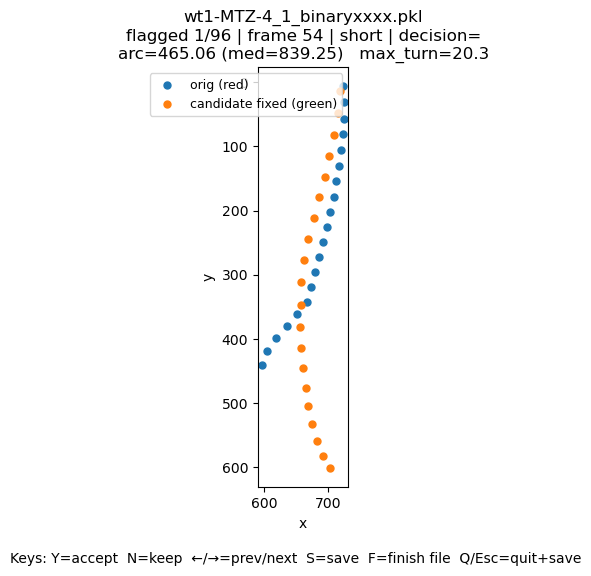


[38/53] Reviewing: wt1-MTZ-4_2_binary.pkl


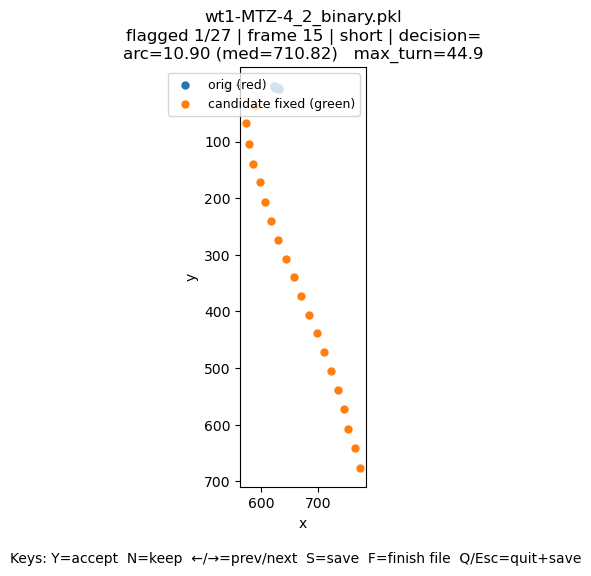


[39/53] Reviewing: wt1-MTZ-4_3_binary.pkl

[40/53] Reviewing: wt1-MTZ-4_4_binary.pkl

[41/53] Reviewing: wt1-MTZ-4_5_binary.pkl


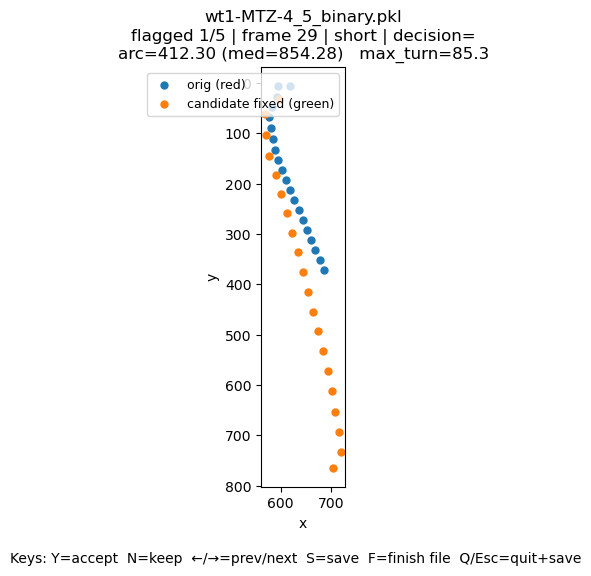


[42/53] Reviewing: wt1-MTZ-4_6_binary.pkl

[43/53] Reviewing: wt1-MTZ-5_1_binary.pkl

[44/53] Reviewing: wt1-MTZ-5_2_binary.pkl

[45/53] Reviewing: wt1-MTZ-5_3_binary.pkl

[46/53] Reviewing: wt1-MTZ-5_4_binary.pkl

[47/53] Reviewing: wt1-MTZ-5_5_binary.pkl

[48/53] Reviewing: wt1-MTZ-5_6_binary.pkl

[49/53] Reviewing: wt1-MTZ-5_7_binary.pkl

[50/53] Reviewing: wt1-MTZ-control-1_0_binary.pkl


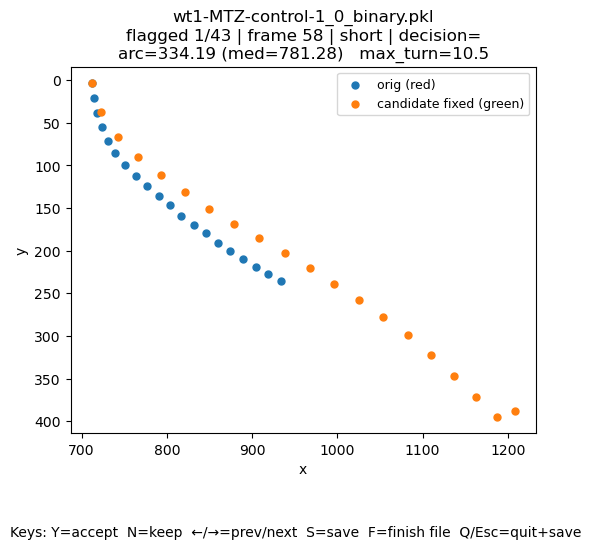


[51/53] Reviewing: wt1-MTZ-control-1_1_binary.pkl


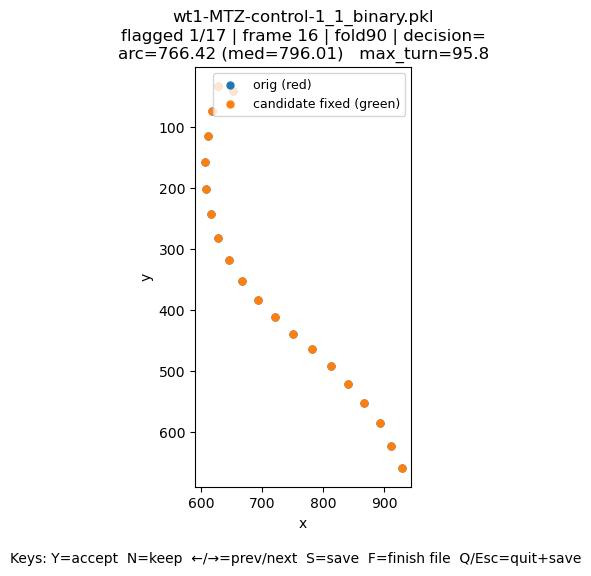


[52/53] Reviewing: wt1-MTZ-control-1_2_binary.pkl

[53/53] Reviewing: wt1-MTZ-control-1_3_binary.pkl
Batch done.
